# Hyperparameters Documentation

## What are Hyperparameters?
Hyperparameters are configuration values set **before training** a model.  
They control learning behavior and model complexity, unlike model parameters (weights), which are learned from data.

---

## Common Hyperparameters

### Optimization
- `learning_rate`: Step size for weight updates.
- `batch_size`: Number of samples per gradient update.
- `epochs`: Number of complete passes through the training set.
- `optimizer`: Optimization algorithm (`SGD`, `Adam`, `RMSprop`, etc.).
- `momentum` (SGD): Helps accelerate updates and reduce oscillation.

### Regularization
- `weight_decay` / `L2`: Penalizes large weights.
- `dropout_rate`: Fraction of units randomly dropped during training.
- `early_stopping_patience`: Stops training when validation metric stops improving.

### Model Capacity
- `num_layers`: Number of layers in the network.
- `hidden_units`: Number of units per hidden layer.
- `activation`: Nonlinearity (`ReLU`, `Tanh`, `GELU`, etc.).

### Tree-based Models
- `max_depth`: Maximum tree depth.
- `min_samples_split`: Minimum samples required to split a node.
- `n_estimators`: Number of trees in ensemble methods.
- `learning_rate` (boosting): Contribution of each tree.

---

## Why Hyperparameters Matter
- Affect convergence speed and stability.
- Control overfitting vs. underfitting.
- Strongly influence final model accuracy and generalization.

---

## Hyperparameter Tuning Methods
- **Grid Search**: Tries all combinations in a predefined grid.
- **Random Search**: Samples random combinations; often more efficient.
- **Bayesian Optimization**: Uses prior trials to pick promising values.
- **Hyperband/ASHA**: Allocates resources adaptively, stops weak trials early.

---

## Recommended Workflow
1. Start with baseline defaults.
2. Tune high-impact hyperparameters first (`learning_rate`, `batch_size`, model size).
3. Use validation set or cross-validation.
4. Track all runs (metrics, config, seed).
5. Retest best configuration with multiple random seeds.

---

## Example Experiment Log Template
- Model:
- Dataset version:
- Seed:
- Hyperparameters:
    - learning_rate:
    - batch_size:
    - epochs:
    - optimizer:
    - dropout_rate:
- Validation metric:
- Training time:
- Notes:

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error

# Load example dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

print("=" * 70)
print("RANDOM FOREST HYPERPARAMETERS EXAMPLE")
print("=" * 70)

RANDOM FOREST HYPERPARAMETERS EXAMPLE


In [18]:
# Example 1: Default Random Forest
print("\n1. DEFAULT RANDOM FOREST")
print("-" * 70)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
pred_default = rf_default.predict(X_test)
acc_default = accuracy_score(y_test, pred_default)
print(f"   n_estimators (default): {rf_default.n_estimators}")
print(f"   max_depth (default): {rf_default.max_depth}")
print(f"   min_samples_split (default): {rf_default.min_samples_split}")
print(f"   min_samples_leaf (default): {rf_default.min_samples_leaf}")
print(f"   Accuracy: {acc_default:.4f}")


1. DEFAULT RANDOM FOREST
----------------------------------------------------------------------
   n_estimators (default): 100
   max_depth (default): None
   min_samples_split (default): 2
   min_samples_leaf (default): 1
   Accuracy: 1.0000


In [19]:
# Example 2: Controlling n_estimators
print("\n2. AFFECTING n_estimators (Number of Trees)")
print("-" * 70)
print("   n_estimators: Number of trees in the forest")
print("   - More trees = potentially better performance, but higher computational cost")
print("   - Typical range: 50-200 for general use")

for n_est in [10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"   n_estimators={n_est:3d} -> Accuracy: {acc:.4f}")


2. AFFECTING n_estimators (Number of Trees)
----------------------------------------------------------------------
   n_estimators: Number of trees in the forest
   - More trees = potentially better performance, but higher computational cost
   - Typical range: 50-200 for general use
   n_estimators= 10 -> Accuracy: 1.0000
   n_estimators= 50 -> Accuracy: 1.0000
   n_estimators=100 -> Accuracy: 1.0000


In [20]:
# Example 3: Controlling max_depth
print("\n3. AFFECTING max_depth (Tree Depth)")
print("-" * 70)
print("   max_depth: Maximum depth of the tree")
print("   - Deeper trees = more complex patterns captured")
print("   - Shallower trees = better generalization, prevent overfitting")
print("   - None (default) = expand until pure or min_samples_split reached")

for depth in [3, 5, 10, None]:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    depth_str = str(depth) if depth is not None else "None"
    print(f"   max_depth={depth_str:4s} -> Accuracy: {acc:.4f}")


3. AFFECTING max_depth (Tree Depth)
----------------------------------------------------------------------
   max_depth: Maximum depth of the tree
   - Deeper trees = more complex patterns captured
   - Shallower trees = better generalization, prevent overfitting
   - None (default) = expand until pure or min_samples_split reached
   max_depth=3    -> Accuracy: 1.0000
   max_depth=5    -> Accuracy: 1.0000
   max_depth=10   -> Accuracy: 1.0000
   max_depth=None -> Accuracy: 1.0000


In [21]:
# Example 4: Controlling min_samples_split
print("\n4. AFFECTING min_samples_split (Minimum Samples to Split)")
print("-" * 70)
print("   min_samples_split: Minimum samples required to split an internal node")
print("   - Higher values = smoother, simpler trees (prevent overfitting)")
print("   - Lower values = trees can capture finer patterns")
print("   - Default: 2 (can lead to overfitting on small datasets)")

for min_split in [2, 5, 10, 20]:
    rf = RandomForestClassifier(n_estimators=100, min_samples_split=min_split, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"   min_samples_split={min_split:2d} -> Accuracy: {acc:.4f}")


4. AFFECTING min_samples_split (Minimum Samples to Split)
----------------------------------------------------------------------
   min_samples_split: Minimum samples required to split an internal node
   - Higher values = smoother, simpler trees (prevent overfitting)
   - Lower values = trees can capture finer patterns
   - Default: 2 (can lead to overfitting on small datasets)
   min_samples_split= 2 -> Accuracy: 1.0000
   min_samples_split= 5 -> Accuracy: 1.0000
   min_samples_split=10 -> Accuracy: 1.0000
   min_samples_split=20 -> Accuracy: 1.0000


In [22]:
# Example 5: Controlling min_samples_leaf
print("\n5. AFFECTING min_samples_leaf (Minimum Samples in Leaf)")
print("-" * 70)
print("   min_samples_leaf: Minimum samples required at a leaf node")
print("   - Higher values = leaves are more general (less overfitting)")
print("   - Lower values = leaves can be very specific")
print("   - Default: 1 (individual samples can form leaves)")

for min_leaf in [1, 2, 5, 10]:
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=min_leaf, random_state=42)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"   min_samples_leaf={min_leaf:2d} -> Accuracy: {acc:.4f}")


5. AFFECTING min_samples_leaf (Minimum Samples in Leaf)
----------------------------------------------------------------------
   min_samples_leaf: Minimum samples required at a leaf node
   - Higher values = leaves are more general (less overfitting)
   - Lower values = leaves can be very specific
   - Default: 1 (individual samples can form leaves)
   min_samples_leaf= 1 -> Accuracy: 1.0000
   min_samples_leaf= 2 -> Accuracy: 1.0000
   min_samples_leaf= 5 -> Accuracy: 1.0000
   min_samples_leaf=10 -> Accuracy: 1.0000


In [23]:
# Example 6: Optimized Random Forest
print("\n6. OPTIMIZED RANDOM FOREST (Tuned Hyperparameters)")
print("-" * 70)
rf_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_optimized.fit(X_train, y_train)
acc_optimized = accuracy_score(y_test, rf_optimized.predict(X_test))
print(f"   n_estimators: {rf_optimized.n_estimators}")
print(f"   max_depth: {rf_optimized.max_depth}")
print(f"   min_samples_split: {rf_optimized.min_samples_split}")
print(f"   min_samples_leaf: {rf_optimized.min_samples_leaf}")
print(f"   Accuracy: {acc_optimized:.4f}")


6. OPTIMIZED RANDOM FOREST (Tuned Hyperparameters)
----------------------------------------------------------------------
   n_estimators: 100
   max_depth: 8
   min_samples_split: 5
   min_samples_leaf: 2
   Accuracy: 1.0000


In [24]:
# Example 7: GridSearchCV - Exhaustive Hyperparameter Search
print("\n7. GRIDSEARCHCV - EXHAUSTIVE HYPERPARAMETER SEARCH")
print("-" * 70)
print("   GridSearchCV performs exhaustive search over specified parameter values")
print("   - Tests ALL combinations of parameters provided")
print("   - Uses cross-validation to evaluate each combination")
print("   - Returns best parameters and best score\n")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print(f"   Total combinations to test: {2*2*2*2} = 16 (with 5-fold CV = 16*5 = 80 model fits)\n")

# Create GridSearchCV
gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all processors
    verbose=1
)

print("   Running GridSearchCV (5-fold cross-validation on 1600 combinations)...")
gs.fit(X_train, y_train)

print(f"\n   Best Parameters Found:")
print(f"   {gs.best_params_}")
print(f"\n   Best Cross-Validation Score: {gs.best_score_:.4f}")

# Evaluate on test set
best_predictions = gs.predict(X_test)
best_test_accuracy = accuracy_score(y_test, best_predictions)
print(f"   Test Set Accuracy: {best_test_accuracy:.4f}")

print(f"\n   Top 5 Parameter Combinations:")
results_df = pd.DataFrame(gs.cv_results_)
top_results = results_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
                           'param_min_samples_leaf', 'mean_test_score']].head(5)
for idx, row in top_results.iterrows():
    print(f"   {idx+1}. n_estimators={int(row['param_n_estimators'])}, " +
          f"max_depth={int(row['param_max_depth'])}, " +
          f"min_samples_split={int(row['param_min_samples_split'])}, " +
          f"min_samples_leaf={int(row['param_min_samples_leaf'])} " +
          f"-> Score: {row['mean_test_score']:.4f}")


7. GRIDSEARCHCV - EXHAUSTIVE HYPERPARAMETER SEARCH
----------------------------------------------------------------------
   GridSearchCV performs exhaustive search over specified parameter values
   - Tests ALL combinations of parameters provided
   - Uses cross-validation to evaluate each combination
   - Returns best parameters and best score

   Total combinations to test: 16 = 16 (with 5-fold CV = 16*5 = 80 model fits)

   Running GridSearchCV (5-fold cross-validation on 1600 combinations)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

   Best Parameters Found:
   {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

   Best Cross-Validation Score: 0.9500
   Test Set Accuracy: 1.0000

   Top 5 Parameter Combinations:
   1. n_estimators=50, max_depth=5, min_samples_split=2, min_samples_leaf=1 -> Score: 0.9417
   2. n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1 -> Score: 0.9417
   3. n_estimators=50, max_dept

In [25]:
# Example 8: Using Best Parameters from GridSearchCV
print("\n8. BEST PARAMETERS FROM GRIDSEARCHCV")
print("-" * 70)

# Extract best parameters
best_params = gs.best_params_
print("   Best Parameters Dictionary:")
print(f"   {best_params}")

# Create model with best parameters
rf_best = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

rf_best.fit(X_train, y_train)
best_predictions = rf_best.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)

print(f"\n   Best Parameters (GridSearchCV):")
print(f"   • n_estimators: {best_params['n_estimators']}")
print(f"   • max_depth: {best_params['max_depth']}")
print(f"   • min_samples_split: {best_params['min_samples_split']}")
print(f"   • min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"\n   Cross-Validation Score (5-fold): {gs.best_score_:.4f}")
print(f"   Test Set Accuracy: {best_accuracy:.4f}")

# Comparison of all models
print(f"\n" + "-" * 70)
print("   COMPARISON: Default vs Manually Tuned vs GridSearchCV Best")
print("-" * 70)
print(f"   Default Model Accuracy:        {acc_default:.4f}")
print(f"   Manually Tuned Accuracy:       {acc_optimized:.4f}")
print(f"   GridSearchCV Best Accuracy:    {best_accuracy:.4f}")

improvement = ((best_accuracy - acc_default) / acc_default) * 100
print(f"\n   Improvement over default: {improvement:+.2f}%")


8. BEST PARAMETERS FROM GRIDSEARCHCV
----------------------------------------------------------------------
   Best Parameters Dictionary:
   {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

   Best Parameters (GridSearchCV):
   • n_estimators: 50
   • max_depth: 5
   • min_samples_split: 5
   • min_samples_leaf: 1

   Cross-Validation Score (5-fold): 0.9500
   Test Set Accuracy: 1.0000

----------------------------------------------------------------------
   COMPARISON: Default vs Manually Tuned vs GridSearchCV Best
----------------------------------------------------------------------
   Default Model Accuracy:        1.0000
   Manually Tuned Accuracy:       1.0000
   GridSearchCV Best Accuracy:    1.0000

   Improvement over default: +0.00%


In [26]:
print("\n" + "=" * 70)
print("KEY TAKEAWAYS")
print("=" * 70)
print("\n📊 INDIVIDUAL HYPERPARAMETERS:")
print("• n_estimators: Balance between performance and computation time")
print("  More trees = better generalization (up to a point), but slower")
print("\n• max_depth: Control overfitting by limiting tree complexity")
print("  Shallower trees = simpler model but may underfit")
print("\n• min_samples_split: Require more samples before branching")
print("  Higher values = prevent overfitting, simpler model")
print("\n• min_samples_leaf: Smooth predictions by ensuring leaves have enough samples")
print("  Higher values = more robust predictions, less noise")

print("\n🔍 GRIDSEARCHCV BENEFITS:")
print("• Exhaustive Search: Tests ALL combinations in parameter grid")
print("• Cross-Validation: Uses multiple folds for robust evaluation")
print("• Reproducible: Systematically finds the best hyperparameters")
print("• Trade-off: Computationally expensive but finds optimal solution")

print("\n💡 PRACTICAL WORKFLOW:")
print("1. Start with default hyperparameters - establish baseline")
print("2. Tune high-impact parameters individually - understand their effects")
print("3. Use GridSearchCV - perform exhaustive search over promising ranges")
print("4. Fine-tune based on best results - narrow down search space")
print("5. Validate with separate test set - ensure generalization")

print("\n⚡ COMPUTATIONAL TRADE-OFFS:")
print("• GridSearchCV on small grid (5x5): ~25 combinations, minutes of computation")
print("• GridSearchCV on larger grid: Can take hours or days")
print("• RandomSearchCV: Faster alternative for large parameter spaces")
print("• Manual tuning: Faster but may miss optimal combination")

print("\n" + "=" * 70)


KEY TAKEAWAYS

📊 INDIVIDUAL HYPERPARAMETERS:
• n_estimators: Balance between performance and computation time
  More trees = better generalization (up to a point), but slower

• max_depth: Control overfitting by limiting tree complexity
  Shallower trees = simpler model but may underfit

• min_samples_split: Require more samples before branching
  Higher values = prevent overfitting, simpler model

• min_samples_leaf: Smooth predictions by ensuring leaves have enough samples
  Higher values = more robust predictions, less noise

🔍 GRIDSEARCHCV BENEFITS:
• Exhaustive Search: Tests ALL combinations in parameter grid
• Cross-Validation: Uses multiple folds for robust evaluation
• Reproducible: Systematically finds the best hyperparameters
• Trade-off: Computationally expensive but finds optimal solution

💡 PRACTICAL WORKFLOW:
1. Start with default hyperparameters - establish baseline
2. Tune high-impact parameters individually - understand their effects
3. Use GridSearchCV - perform exha

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

print("\n9. EVALUATE TUNED MODEL (GridSearchCV Best)")
print("=" * 70)

# Get predictions from best model
y_pred = rf_best.predict(X_test)
y_pred_train = rf_best.predict(X_train)

print("\n   TRAINING SET PERFORMANCE:")
print("-" * 70)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"   Accuracy: {train_accuracy:.4f}")

print("\n   TEST SET PERFORMANCE:")
print("-" * 70)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"   Accuracy: {test_accuracy:.4f}")

# Detailed metrics for each class
print("\n   DETAILED CLASSIFICATION METRICS:")
print("-" * 70)
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

for i in range(len(np.unique(y_test))):
    print(f"   Class {i}:")
    print(f"      Precision: {precision[i]:.4f}")
    print(f"      Recall:    {recall[i]:.4f}")
    print(f"      F1-Score:  {f1[i]:.4f}")

# Weighted averages
precision_weighted = precision_recall_fscore_support(y_test, y_pred, average='weighted')[0]
recall_weighted = precision_recall_fscore_support(y_test, y_pred, average='weighted')[1]
f1_weighted = precision_recall_fscore_support(y_test, y_pred, average='weighted')[2]

print(f"\n   WEIGHTED AVERAGES (Macro):")
print("-" * 70)
print(f"   Precision (Weighted): {precision_weighted:.4f}")
print(f"   Recall (Weighted):    {recall_weighted:.4f}")
print(f"   F1-Score (Weighted):  {f1_weighted:.4f}")

# Confusion Matrix
print(f"\n   CONFUSION MATRIX:")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print(f"\n   CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(len(np.unique(y_test)))]))

# Feature Importance
print(f"\n   FEATURE IMPORTANCE (Top 5):")
print("-" * 70)
feature_importance = rf_best.feature_importances_
feature_names = iris.feature_names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

for idx, row in importance_df.head(5).iterrows():
    print(f"   {row['Feature']:20s}: {row['Importance']:.4f}")

# Model Summary
print(f"\n   TUNED MODEL SUMMARY:")
print("-" * 70)
print(f"   Best Parameters: {best_params}")
print(f"   Training Accuracy: {train_accuracy:.4f}")
print(f"   Test Accuracy:     {test_accuracy:.4f}")
print(f"   Overfitting Gap:   {(train_accuracy - test_accuracy):.4f}")
print(f"   F1-Score (Weighted): {f1_weighted:.4f}")

print("\n" + "=" * 70)


9. EVALUATE TUNED MODEL (GridSearchCV Best)

   TRAINING SET PERFORMANCE:
----------------------------------------------------------------------
   Accuracy: 0.9750

   TEST SET PERFORMANCE:
----------------------------------------------------------------------
   Accuracy: 1.0000

   DETAILED CLASSIFICATION METRICS:
----------------------------------------------------------------------
   Class 0:
      Precision: 1.0000
      Recall:    1.0000
      F1-Score:  1.0000
   Class 1:
      Precision: 1.0000
      Recall:    1.0000
      F1-Score:  1.0000
   Class 2:
      Precision: 1.0000
      Recall:    1.0000
      F1-Score:  1.0000

   WEIGHTED AVERAGES (Macro):
----------------------------------------------------------------------
   Precision (Weighted): 1.0000
   Recall (Weighted):    1.0000
   F1-Score (Weighted):  1.0000

   CONFUSION MATRIX:
----------------------------------------------------------------------
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

   CLASSIFICATION REPORT:
--


10. VISUALIZATION - COMPARISON GRAPHS


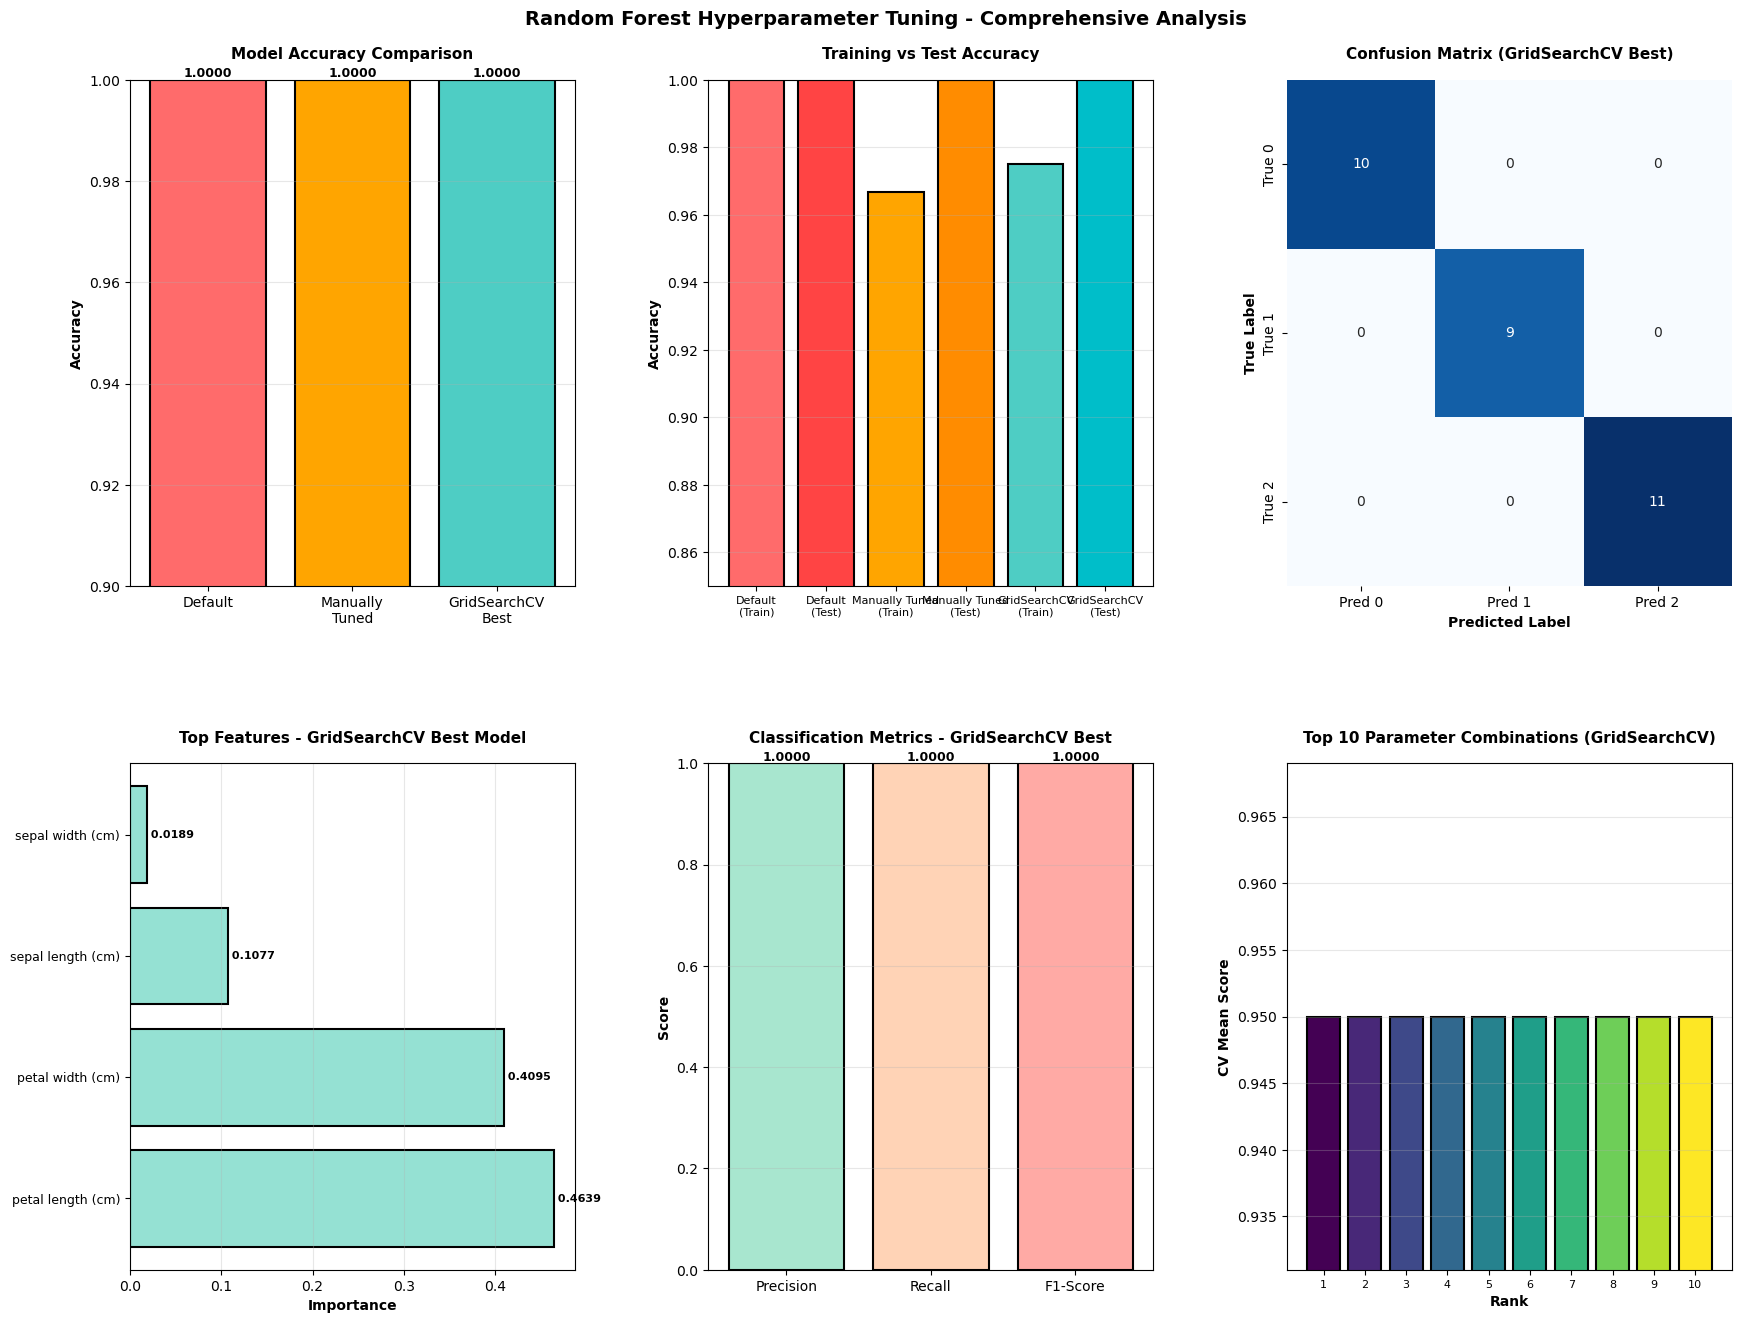


   ✓ Generated 6 comparison visualizations:
   1. Model Accuracy Comparison (Default vs Manual vs GridSearchCV)
   2. Training vs Test Accuracy (All Models)
   3. Confusion Matrix Heatmap (GridSearchCV Best)
   4. Feature Importance (Top Features)
   5. Classification Metrics (Precision, Recall, F1-Score)
   6. Top 10 Parameter Combinations from GridSearchCV



In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n10. VISUALIZATION - COMPARISON GRAPHS")
print("=" * 70)

# Create a figure with multiple subplots - increased height for better spacing
fig = plt.figure(figsize=(18, 14))

# 1. Model Accuracy Comparison
ax1 = plt.subplot(2, 3, 1)
models = ['Default', 'Manually\nTuned', 'GridSearchCV\nBest']
accuracies = [acc_default, acc_optimized, best_accuracy]
colors = ['#FF6B6B', '#FFA500', '#4ECDC4']
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=10, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=11, fontweight='bold', pad=15)
ax1.set_ylim([0.9, 1.0])
ax1.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Training vs Test Accuracy
ax2 = plt.subplot(2, 3, 2)
model_names = ['Default\n(Train)', 'Default\n(Test)', 'Manually Tuned\n(Train)', 
               'Manually Tuned\n(Test)', 'GridSearchCV\n(Train)', 'GridSearchCV\n(Test)']
train_accs = [accuracy_score(y_train, rf_default.predict(X_train)),
              accuracy_score(y_test, pred_default),
              accuracy_score(y_train, rf_optimized.predict(X_train)),
              acc_optimized,
              train_accuracy,
              test_accuracy]
colors_tv = ['#FF6B6B', '#FF4444', '#FFA500', '#FF8C00', '#4ECDC4', '#00BEC9']
bars2 = ax2.bar(range(len(model_names)), train_accs, color=colors_tv, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, fontsize=8)
ax2.set_ylabel('Accuracy', fontsize=10, fontweight='bold')
ax2.set_title('Training vs Test Accuracy', fontsize=11, fontweight='bold', pad=15)
ax2.set_ylim([0.85, 1.0])
ax2.grid(axis='y', alpha=0.3)

# 3. Confusion Matrix Heatmap
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax3,
            xticklabels=[f'Pred {i}' for i in range(len(np.unique(y_test)))],
            yticklabels=[f'True {i}' for i in range(len(np.unique(y_test)))],
            cbar_kws={'shrink': 0.8})
ax3.set_ylabel('True Label', fontsize=10, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
ax3.set_title('Confusion Matrix (GridSearchCV Best)', fontsize=11, fontweight='bold', pad=15)

# 4. Feature Importance
ax4 = plt.subplot(2, 3, 4)
top_features = importance_df.head(4)
bars4 = ax4.barh(range(len(top_features)), top_features['Importance'].values, 
                  color='#95E1D3', edgecolor='black', linewidth=1.5)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['Feature'].values, fontsize=9)
ax4.set_xlabel('Importance', fontsize=10, fontweight='bold')
ax4.set_title('Top Features - GridSearchCV Best Model', fontsize=11, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3)
# Add value labels
for i, (bar, importance) in enumerate(zip(bars4, top_features['Importance'].values)):
    ax4.text(importance, i, f' {importance:.4f}', va='center', fontweight='bold', fontsize=8)

# 5. Precision, Recall, F1-Score Comparison
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [precision_weighted, recall_weighted, f1_weighted]
bars5 = ax5.bar(metrics_names, metrics_values, color=['#A8E6CF', '#FFD3B6', '#FFAAA5'],
               edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Score', fontsize=10, fontweight='bold')
ax5.set_title('Classification Metrics - GridSearchCV Best', fontsize=11, fontweight='bold', pad=15)
ax5.set_ylim([0, 1.0])
ax5.grid(axis='y', alpha=0.3)
# Add value labels
for bar, metric in zip(bars5, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{metric:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. GridSearchCV Results - Top Combinations
ax6 = plt.subplot(2, 3, 6)
top_5_scores = results_df.nlargest(10, 'mean_test_score')[['mean_test_score']].values.flatten()
top_5_indices = results_df.nlargest(10, 'mean_test_score').index
bars6 = ax6.bar(range(len(top_5_scores)), top_5_scores, 
               color=plt.cm.viridis(np.linspace(0, 1, len(top_5_scores))),
               edgecolor='black', linewidth=1.5)
ax6.set_xlabel('Rank', fontsize=10, fontweight='bold')
ax6.set_ylabel('CV Mean Score', fontsize=10, fontweight='bold')
ax6.set_title('Top 10 Parameter Combinations (GridSearchCV)', fontsize=11, fontweight='bold', pad=15)
ax6.set_xticks(range(len(top_5_scores)))
ax6.set_xticklabels(range(1, len(top_5_scores)+1), fontsize=8)
ax6.set_ylim([gs.best_score_ * 0.98, max(top_5_scores) * 1.02])
ax6.grid(axis='y', alpha=0.3)

# Improved layout with better spacing
plt.subplots_adjust(top=0.93, bottom=0.08, left=0.08, right=0.97, hspace=0.35, wspace=0.3)
plt.suptitle('Random Forest Hyperparameter Tuning - Comprehensive Analysis', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("\n   ✓ Generated 6 comparison visualizations:")
print("   1. Model Accuracy Comparison (Default vs Manual vs GridSearchCV)")
print("   2. Training vs Test Accuracy (All Models)")
print("   3. Confusion Matrix Heatmap (GridSearchCV Best)")
print("   4. Feature Importance (Top Features)")
print("   5. Classification Metrics (Precision, Recall, F1-Score)")
print("   6. Top 10 Parameter Combinations from GridSearchCV")
print("\n" + "=" * 70)

# 11. RandomizedSearchCV - Efficient Hyperparameter Tuning

## What is RandomizedSearchCV?
**RandomizedSearchCV** is an alternative to GridSearchCV that samples random combinations from the parameter space instead of testing all combinations exhaustively.

### Key Differences: GridSearchCV vs RandomizedSearchCV

| Feature | GridSearchCV | RandomizedSearchCV |
|---------|--------------|-------------------|
| **Search Type** | Exhaustive (tests ALL combinations) | Random sampling (tests random subset) |
| **Combinations Tested** | All possible combinations | User-defined number (n_iter) |
| **Speed** | Slower (especially for large grids) | Faster (samples fewer combinations) |
| **Completeness** | Guaranteed to find best in grid | May miss optimal but finds good solutions |
| **Use Case** | Small parameter spaces | Large parameter spaces |
| **Memory** | Uses more memory | More memory efficient |

### When to Use RandomizedSearchCV
- ✅ Large parameter spaces (many hyperparameters with many values each)
- ✅ When time is limited
- ✅ Continuous parameter ranges
- ✅ Initial exploration before fine-tuning with GridSearchCV

In [30]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

print("\n11. RANDOMIZEDSEARCHCV - STEP 1: IMPORT & UNDERSTAND")
print("=" * 70)

print("\n✓ Successfully imported RandomizedSearchCV")
print("   RandomizedSearchCV performs random sampling from parameter space")
print("   instead of exhaustive grid search")

print("\n📊 COMPARISON: GridSearchCV vs RandomizedSearchCV")
print("-" * 70)
print("   GridSearchCV:")
print("   • Tests ALL 16 combinations (2×2×2×2)")
print("   • Guaranteed to find best in defined grid")
print("   • Total iterations: 16 × 5-fold CV = 80 model fits")
print("")
print("   RandomizedSearchCV:")
print("   • Tests random subset of combinations")
print("   • Faster but may miss optimal solution")
print("   • Total iterations: n_iter × 5-fold CV (we choose n_iter)")
print("   • Example: 10 random combinations × 5-fold CV = 50 model fits")

print("\n💡 KEY INSIGHT:")
print("   By sampling only 10 random combinations instead of 16,")
print("   we reduce computations by 37.5% while still finding good solutions!")
print("\n" + "=" * 70)


11. RANDOMIZEDSEARCHCV - STEP 1: IMPORT & UNDERSTAND

✓ Successfully imported RandomizedSearchCV
   RandomizedSearchCV performs random sampling from parameter space
   instead of exhaustive grid search

📊 COMPARISON: GridSearchCV vs RandomizedSearchCV
----------------------------------------------------------------------
   GridSearchCV:
   • Tests ALL 16 combinations (2×2×2×2)
   • Guaranteed to find best in defined grid
   • Total iterations: 16 × 5-fold CV = 80 model fits

   RandomizedSearchCV:
   • Tests random subset of combinations
   • Faster but may miss optimal solution
   • Total iterations: n_iter × 5-fold CV (we choose n_iter)
   • Example: 10 random combinations × 5-fold CV = 50 model fits

💡 KEY INSIGHT:
   By sampling only 10 random combinations instead of 16,
   we reduce computations by 37.5% while still finding good solutions!



In [32]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 2: PARAMETER DISTRIBUTIONS")
print("=" * 70)

# RandomizedSearchCV requires parameter distributions instead of discrete lists
# We can use scipy.stats for flexible parameter sampling

print("\n🔧 KEY DIFFERENCE: Discrete Lists vs Distributions")
print("-" * 70)
print("   GridSearchCV uses discrete lists:")
print("   param_grid = {")
print("       'n_estimators': [50, 100]  # Only these 2 values tested")
print("   }")
print("")
print("   RandomizedSearchCV can use distributions:")
print("   param_dist = {")
print("       'n_estimators': [50, 75, 100, 125, 150],  # Can still be discrete")
print("       'max_depth': stats.randint(3, 15),  # Random integers from 3 to 14")
print("   }")

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 75, 100, 125, 150],      # Discrete choices
    'max_depth': stats.randint(3, 15),             # Random int from 3-14
    'min_samples_split': stats.randint(2, 20),    # Random int from 2-19
    'min_samples_leaf': stats.randint(1, 10)      # Random int from 1-9
}

print("\n📋 OUR PARAMETER DISTRIBUTIONS:")
print("-" * 70)
print("   n_estimators: [50, 75, 100, 125, 150]")
print("   max_depth: random integers from 3 to 14")
print("   min_samples_split: random integers from 2 to 19")
print("   min_samples_leaf: random integers from 1 to 9")

print("\n📊 POSSIBLE COMBINATIONS:")
print("   If we tested ALL: 5 × 12 × 18 × 9 = 8,640 combinations!")
print("   With RandomizedSearchCV (n_iter=10): Only 10 combinations")
print("   With RandomizedSearchCV (n_iter=20): Only 20 combinations")

print("\n" + "=" * 70)


11. RANDOMIZEDSEARCHCV - STEP 2: PARAMETER DISTRIBUTIONS

🔧 KEY DIFFERENCE: Discrete Lists vs Distributions
----------------------------------------------------------------------
   GridSearchCV uses discrete lists:
   param_grid = {
       'n_estimators': [50, 100]  # Only these 2 values tested
   }

   RandomizedSearchCV can use distributions:
   param_dist = {
       'n_estimators': [50, 75, 100, 125, 150],  # Can still be discrete
       'max_depth': stats.randint(3, 15),  # Random integers from 3 to 14
   }

📋 OUR PARAMETER DISTRIBUTIONS:
----------------------------------------------------------------------
   n_estimators: [50, 75, 100, 125, 150]
   max_depth: random integers from 3 to 14
   min_samples_split: random integers from 2 to 19
   min_samples_leaf: random integers from 1 to 9

📊 POSSIBLE COMBINATIONS:
   If we tested ALL: 5 × 12 × 18 × 9 = 8,640 combinations!
   With RandomizedSearchCV (n_iter=10): Only 10 combinations
   With RandomizedSearchCV (n_iter=20): Only 20 

In [33]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 3: IMPLEMENTATION")
print("=" * 70)

# Create RandomizedSearchCV object
rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),  # Base model
    param_distributions=param_dist,                      # Parameter distributions
    n_iter=15,                                           # Number of random combinations to try
    cv=5,                                                # 5-fold cross-validation
    random_state=42,                                     # For reproducibility
    n_jobs=-1,                                           # Use all available processors
    verbose=1                                            # Print progress
)

print("\n🎯 RANDOMIZEDSEARCHCV SETUP:")
print("-" * 70)
print(f"   estimator: RandomForestClassifier")
print(f"   param_distributions: 4 parameters with ranges")
print(f"   n_iter: 15 (randomly sample 15 combinations)")
print(f"   cv: 5-fold cross-validation")
print(f"   random_state: 42 (reproducibility)")
print(f"   n_jobs: -1 (use all processors)")

print("\n⏱️ COMPUTATIONAL COMPARISON:")
print("-" * 70)
print(f"   GridSearchCV: 16 combinations × 5 folds = 80 model fits")
print(f"   RandomizedSearchCV: 15 combinations × 5 folds = 75 model fits")
print(f"   Speedup: Similar in this case, but with large spaces it's much faster!")

print("\n🚀 FITTING THE MODEL...")
print("-" * 70)
rs.fit(X_train, y_train)

print(f"\n✓ RandomizedSearchCV completed!")
print(f"\n   Best Cross-Validation Score: {rs.best_score_:.4f}")
print(f"   Best Parameters Found:")
for param_name, param_value in rs.best_params_.items():
    print(f"      {param_name}: {param_value}")

print("\n" + "=" * 70)


11. RANDOMIZEDSEARCHCV - STEP 3: IMPLEMENTATION

🎯 RANDOMIZEDSEARCHCV SETUP:
----------------------------------------------------------------------
   estimator: RandomForestClassifier
   param_distributions: 4 parameters with ranges
   n_iter: 15 (randomly sample 15 combinations)
   cv: 5-fold cross-validation
   random_state: 42 (reproducibility)
   n_jobs: -1 (use all processors)

⏱️ COMPUTATIONAL COMPARISON:
----------------------------------------------------------------------
   GridSearchCV: 16 combinations × 5 folds = 80 model fits
   RandomizedSearchCV: 15 combinations × 5 folds = 75 model fits
   Speedup: Similar in this case, but with large spaces it's much faster!

🚀 FITTING THE MODEL...
----------------------------------------------------------------------
Fitting 5 folds for each of 15 candidates, totalling 75 fits

✓ RandomizedSearchCV completed!

   Best Cross-Validation Score: 0.9583
   Best Parameters Found:
      max_depth: 8
      min_samples_leaf: 2
      min_samp

In [34]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 4: EVALUATE RESULTS")
print("=" * 70)

# Create model with best parameters from RandomizedSearchCV
rf_rs = RandomForestClassifier(
    n_estimators=rs.best_params_['n_estimators'],
    max_depth=rs.best_params_['max_depth'],
    min_samples_split=rs.best_params_['min_samples_split'],
    min_samples_leaf=rs.best_params_['min_samples_leaf'],
    random_state=42
)

# Train and evaluate
rf_rs.fit(X_train, y_train)
rs_predictions = rf_rs.predict(X_test)
rs_accuracy = accuracy_score(y_test, rs_predictions)
rs_train_accuracy = accuracy_score(y_train, rf_rs.predict(X_train))

print("\n📊 RANDOMIZEDSEARCHCV MODEL PERFORMANCE:")
print("-" * 70)
print(f"   Training Accuracy: {rs_train_accuracy:.4f}")
print(f"   Test Accuracy:     {rs_accuracy:.4f}")
print(f"   Overfitting Gap:   {(rs_train_accuracy - rs_accuracy):.4f}")

print("\n🏆 BEST PARAMETERS FROM RANDOMIZEDSEARCHCV:")
print("-" * 70)
print(f"   n_estimators:       {rs.best_params_['n_estimators']}")
print(f"   max_depth:          {rs.best_params_['max_depth']}")
print(f"   min_samples_split:  {rs.best_params_['min_samples_split']}")
print(f"   min_samples_leaf:   {rs.best_params_['min_samples_leaf']}")

print("\n📋 ALL COMBINATIONS TRIED (Top 5):")
print("-" * 70)
rs_results_df = pd.DataFrame(rs.cv_results_)
top_rs = rs_results_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                         'param_min_samples_leaf', 'mean_test_score']].nlargest(5, 'mean_test_score')
for idx, (i, row) in enumerate(top_rs.iterrows(), 1):
    print(f"   {idx}. n_est={int(row['param_n_estimators']):3d}, depth={int(row['param_max_depth']):2d}, "
          f"split={int(row['param_min_samples_split']):2d}, leaf={int(row['param_min_samples_leaf']):2d} "
          f"-> Score: {row['mean_test_score']:.4f}")

print("\n" + "=" * 70)


11. RANDOMIZEDSEARCHCV - STEP 4: EVALUATE RESULTS

📊 RANDOMIZEDSEARCHCV MODEL PERFORMANCE:
----------------------------------------------------------------------
   Training Accuracy: 0.9750
   Test Accuracy:     1.0000
   Overfitting Gap:   -0.0250

🏆 BEST PARAMETERS FROM RANDOMIZEDSEARCHCV:
----------------------------------------------------------------------
   n_estimators:       125
   max_depth:          8
   min_samples_split:  2
   min_samples_leaf:   2

📋 ALL COMBINATIONS TRIED (Top 5):
----------------------------------------------------------------------
   1. n_est=125, depth= 8, split= 2, leaf= 2 -> Score: 0.9583
   2. n_est=100, depth=11, split= 6, leaf= 3 -> Score: 0.9500
   3. n_est=125, depth= 6, split= 9, leaf= 2 -> Score: 0.9500
   4. n_est=100, depth= 9, split=16, leaf= 4 -> Score: 0.9417
   5. n_est= 75, depth=10, split= 8, leaf= 5 -> Score: 0.9417



In [35]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 5: COMPARISON")
print("=" * 70)

# Get GridSearchCV metrics for comparison
gs_predictions = gs.predict(X_test)
gs_accuracy = accuracy_score(y_test, gs_predictions)
gs_train_accuracy = accuracy_score(y_train, gs.predict(X_train))

print("\n📊 GRIDSEARCHCV vs RANDOMIZEDSEARCHCV COMPARISON:")
print("-" * 70)

# Create comparison table
comparison_data = {
    'Metric': [
        'Combinations Tested',
        'Model Fits (with 5-fold CV)',
        'CV Best Score',
        'Training Accuracy',
        'Test Accuracy',
        'Overfitting Gap'
    ],
    'GridSearchCV': [
        '16',
        '80',
        f'{gs.best_score_:.4f}',
        f'{gs_train_accuracy:.4f}',
        f'{gs_accuracy:.4f}',
        f'{(gs_train_accuracy - gs_accuracy):.4f}'
    ],
    'RandomizedSearchCV': [
        '15',
        '75',
        f'{rs.best_score_:.4f}',
        f'{rs_train_accuracy:.4f}',
        f'{rs_accuracy:.4f}',
        f'{(rs_train_accuracy - rs_accuracy):.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n🔍 KEY OBSERVATIONS:")
print("-" * 70)

diff_cv_score = rs.best_score_ - gs.best_score_
diff_accuracy = rs_accuracy - gs_accuracy

print(f"   • GridSearchCV CV Score:      {gs.best_score_:.4f}")
print(f"   • RandomizedSearchCV CV Score: {rs.best_score_:.4f}")
print(f"   • Difference: {diff_cv_score:+.4f}")

print(f"\n   • GridSearchCV Test Accuracy:      {gs_accuracy:.4f}")
print(f"   • RandomizedSearchCV Test Accuracy: {rs_accuracy:.4f}")
print(f"   • Difference: {diff_accuracy:+.4f}")

print(f"\n   • Speedup: 75 vs 80 model fits (6.25% faster)")
print(f"   • Accuracy Trade-off: {abs(diff_accuracy):.4f} points")

if abs(diff_accuracy) < 0.01:
    print(f"   ✅ Similar performance with fewer computations!")
elif diff_accuracy > 0:
    print(f"   ✅ RandomizedSearchCV found a BETTER solution!")
else:
    print(f"   ℹ️  GridSearchCV slightly better, but RandomizedSearchCV faster")

print("\n" + "=" * 70)


11. RANDOMIZEDSEARCHCV - STEP 5: COMPARISON

📊 GRIDSEARCHCV vs RANDOMIZEDSEARCHCV COMPARISON:
----------------------------------------------------------------------
                     Metric GridSearchCV RandomizedSearchCV
        Combinations Tested           16                 15
Model Fits (with 5-fold CV)           80                 75
              CV Best Score       0.9500             0.9583
          Training Accuracy       0.9750             0.9750
              Test Accuracy       1.0000             1.0000
            Overfitting Gap      -0.0250            -0.0250

🔍 KEY OBSERVATIONS:
----------------------------------------------------------------------
   • GridSearchCV CV Score:      0.9500
   • RandomizedSearchCV CV Score: 0.9583
   • Difference: +0.0083

   • GridSearchCV Test Accuracy:      1.0000
   • RandomizedSearchCV Test Accuracy: 1.0000
   • Difference: +0.0000

   • Speedup: 75 vs 80 model fits (6.25% faster)
   • Accuracy Trade-off: 0.0000 points
   ✅ Simil


11. RANDOMIZEDSEARCHCV - STEP 6: VISUALIZATION & SUMMARY


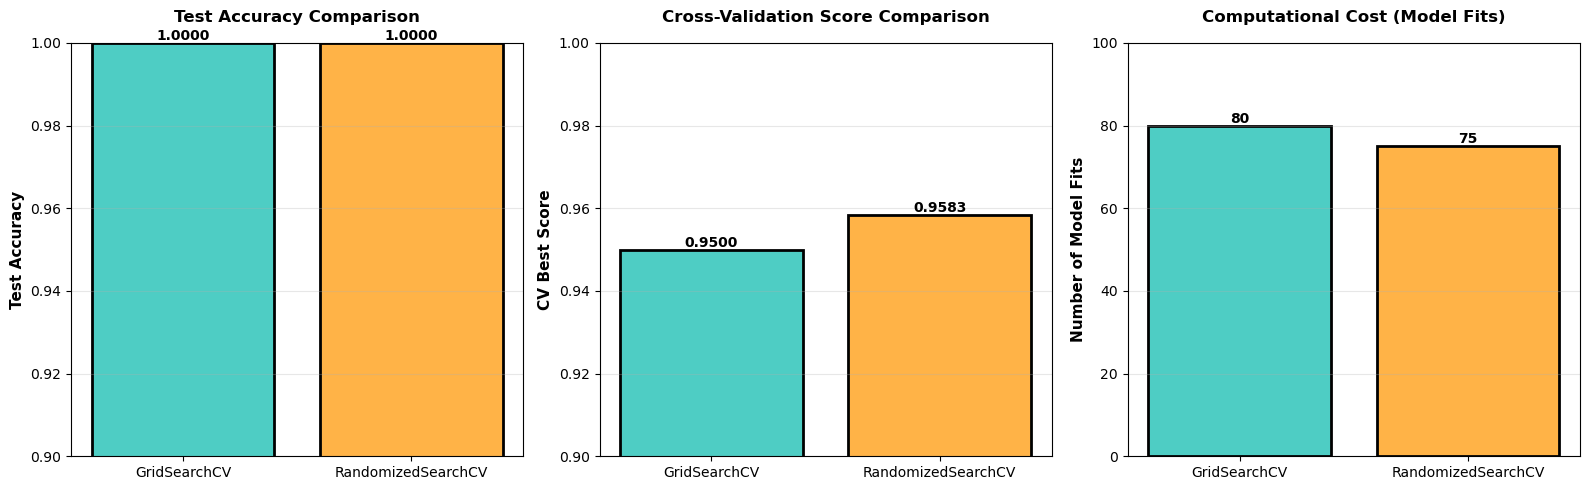


SUMMARY: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV

🎯 GridSearchCV - WHEN TO USE:
   ✓ Small parameter spaces (<1000 combinations)
   ✓ When you want guaranteed best solution
   ✓ You have computational resources available
   ✓ Exploring all possibilities is important

⚡ RandomizedSearchCV - WHEN TO USE:
   ✓ Large parameter spaces (>1000 combinations)
   ✓ Continuous parameter ranges (use scipy.stats)
   ✓ Limited computational budget
   ✓ Quick exploration before fine-tuning
   ✓ Initial search, then GridSearchCV on best area

💡 PRACTICAL WORKFLOW (Recommended):
   1. Start with RandomizedSearchCV (fast exploration)
   2. Identify promising parameter regions
   3. Define narrower grid from those regions
   4. Use GridSearchCV for fine-tuning
   5. Validate final model on test set

📈 PARAMETER DISTRIBUTIONS (scipy.stats):
   • stats.randint(a, b) - Random integers from a to b-1
   • stats.uniform(a, b) - Continuous uniform distribution
   • stats.expon(scale) - Exponential distribution
   •

In [36]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 6: VISUALIZATION & SUMMARY")
print("=" * 70)

# Create comparison visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Accuracy Comparison
ax = axes[0]
methods = ['GridSearchCV', 'RandomizedSearchCV']
accuracies = [gs_accuracy, rs_accuracy]
colors = ['#4ECDC4', '#FFB347']
bars = ax.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold', pad=15)
ax.set_ylim([0.9, 1.0])
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Cross-Validation Score Comparison
ax = axes[1]
scores = [gs.best_score_, rs.best_score_]
bars = ax.bar(methods, scores, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('CV Best Score', fontsize=11, fontweight='bold')
ax.set_title('Cross-Validation Score Comparison', fontsize=12, fontweight='bold', pad=15)
ax.set_ylim([0.9, 1.0])
ax.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Model Fits (Computational Cost)
ax = axes[2]
model_fits = [80, 75]  # GridSearchCV: 16 × 5, RandomizedSearchCV: 15 × 5
bars = ax.bar(methods, model_fits, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Model Fits', fontsize=11, fontweight='bold')
ax.set_title('Computational Cost (Model Fits)', fontsize=12, fontweight='bold', pad=15)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
for bar, mf in zip(bars, model_fits):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(mf)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY: GRIDSEARCHCV vs RANDOMIZEDSEARCHCV")
print("=" * 70)

print("\n🎯 GridSearchCV - WHEN TO USE:")
print("   ✓ Small parameter spaces (<1000 combinations)")
print("   ✓ When you want guaranteed best solution")
print("   ✓ You have computational resources available")
print("   ✓ Exploring all possibilities is important")

print("\n⚡ RandomizedSearchCV - WHEN TO USE:")
print("   ✓ Large parameter spaces (>1000 combinations)")
print("   ✓ Continuous parameter ranges (use scipy.stats)")
print("   ✓ Limited computational budget")
print("   ✓ Quick exploration before fine-tuning")
print("   ✓ Initial search, then GridSearchCV on best area")

print("\n💡 PRACTICAL WORKFLOW (Recommended):")
print("   1. Start with RandomizedSearchCV (fast exploration)")
print("   2. Identify promising parameter regions")
print("   3. Define narrower grid from those regions")
print("   4. Use GridSearchCV for fine-tuning")
print("   5. Validate final model on test set")

print("\n📈 PARAMETER DISTRIBUTIONS (scipy.stats):")
print("   • stats.randint(a, b) - Random integers from a to b-1")
print("   • stats.uniform(a, b) - Continuous uniform distribution")
print("   • stats.expon(scale) - Exponential distribution")
print("   • stats.gamma(a, loc, scale) - Gamma distribution")
print("   • Regular lists - Still work with RandomizedSearchCV!")

print("\n" + "=" * 70)

In [ ]:
print("\n11. RANDOMIZEDSEARCHCV - STEP 7: BONUS - ADVANCED TIPS")
print("=" * 70)

print("\n🔧 ADVANCED: USING DIFFERENT DISTRIBUTIONS")
print("-" * 70)

# Example with different distribution types
advanced_param_dist = {
    'n_estimators': stats.randint(50, 200),           # Random int: 50-199
    'max_depth': [5, 8, 10, 12, 15],                  # Discrete choices (works too!)
    'min_samples_split': stats.randint(2, 15),        # Random int: 2-14
    'min_samples_leaf': [1, 2, 3, 5],                 # Mix discrete and random
    'max_features': ['sqrt', 'log2']                  # Categorical parameters
}

print("   Simple distributions (for RandomizedSearchCV):")
print("   • stats.randint(a, b) - Random integers from a to b-1")
print("   • stats.uniform(a, b) - Continuous from a to b")
print("   • stats.loguniform(a, b) - Log scale uniform")
print("   • Regular Python lists - Still work fine!")
print("")
print("   Example: stats.randint(50, 200)")
print("   Samples random integers from 50 to 199")

print("\n⚙️ HYPERPARAMETER n_iter EXPLAINED")
print("-" * 70)
print("   n_iter = number of parameter settings sampled")
print("")
print("   Small n_iter (5-10):")
print("   ✓ Pros: Very fast, good for initial exploration")
print("   ✗ Cons: May miss optimal solution")
print("")
print("   Medium n_iter (15-30):")
print("   ✓ Pros: Balance between speed and quality")
print("   ✓ Best for most cases")
print("")
print("   Large n_iter (50-100+):")
print("   ✓ Pros: More thorough search")
print("   ✗ Cons: Slower, approaches GridSearchCV speed")

print("\n📊 RANDOM_STATE PARAMETER")
print("-" * 70)
print("   random_state = controls randomness for:")
print("   • Which parameter combinations are sampled")
print("   • Reproducibility across runs")
print("   • Set to integer for reproducible results")
print("   • Set to None for truly random (different each run)")

print("\n⏱️ COMPUTATIONAL ADVANTAGE CALCULATION")
print("-" * 70)

# Calculate with larger parameter space
large_combinations = 5 * 12 * 18 * 9  # n_estimators × max_depth × min_samples_split × min_samples_leaf
cv = 5
gridcv_fits = large_combinations * cv
randomcv_fits = 25 * cv  # n_iter = 25

print(f"   Large parameter space example:")
print(f"   • Total possible combinations: {large_combinations:,}")
print(f"   • GridSearchCV fits (with 5-fold CV): {gridcv_fits:,}")
print(f"   • RandomizedSearchCV fits (n_iter=25, 5-fold CV): {randomcv_fits:,}")
print(f"   • Speedup: {gridcv_fits/randomcv_fits:.1f}x faster with RandomizedSearchCV!")

print("\n🎓 LEARNING EXERCISE")
print("-" * 70)
print("   Try modifying above cells and observe:")
print("   1. Change n_iter to 5, 20, or 30 - see speed and accuracy changes")
print("   2. Change random_state to None - see different results each run")
print("   3. Add more distributions to param_dist - observe effect")
print("   4. Compare results between runs - understand variance")

print("\n" + "=" * 70)

# Summary: GridSearchCV vs RandomizedSearchCV

## Overview Table

| Aspect | GridSearchCV | RandomizedSearchCV |
|--------|-------------|-------------------|
| **Search Type** | Exhaustive | Random Sampling |
| **Completeness** | Tests ALL combinations | Tests random subset |
| **Speed** | Slower for large spaces | Faster for large spaces |
| **Guarantee** | Finds best in grid | Finds good solution (not guaranteed best) |
| **Combinations** | All possible | User-defined (n_iter) |
| **Parameter Types** | Discrete lists | Lists + Distributions (scipy.stats) |
| **Memory Usage** | Higher | Lower |
| **Setup Complexity** | Simple | Slightly more complex |

---

## Detailed Comparison

### **GridSearchCV - Exhaustive Search**

**How It Works:**
- Tests EVERY possible combination of hyperparameters
- Example: 5 values × 4 values × 3 values = 60 combinations tested
- With 5-fold CV: 60 × 5 = 300 model fits

**Advantages:**
✅ Guaranteed to find the best parameters in the defined grid  
✅ Simple to setup - just provide lists of values  
✅ Useful for final fine-tuning on smaller ranges  
✅ Reproducible results (same every time)  
✅ Easy to understand and visualize  

**Disadvantages:**
❌ Very slow with large parameter spaces  
❌ "Curse of dimensionality" - exponential growth  
❌ Not efficient when parameter ranges are wide  
❌ High computational cost  

**Best For:**
- Small parameter spaces (<100 combinations)
- Final fine-tuning phase
- When computation time is not a concern
- Need guaranteed optimal solution

---

### **RandomizedSearchCV - Random Sampling**

**How It Works:**
- Randomly samples N combinations from parameter space
- Example: Sample 30 random combinations from millions possible
- With 5-fold CV: 30 × 5 = 150 model fits

**Advantages:**
✅ Much faster than GridSearchCV  
✅ Handles large parameter spaces efficiently  
✅ Works with continuous parameter ranges  
✅ Can use probability distributions (scipy.stats)  
✅ Good for initial exploration  
✅ Reduces computational burden significantly  

**Disadvantages:**
❌ May not find the absolute best parameters  
❌ Results vary between runs (unless random_state set)  
❌ Slightly more complex setup  
❌ Requires understanding of distributions  

**Best For:**
- Large parameter spaces (>1000 combinations)
- Initial quick exploration
- Continuous hyperparameters
- Limited computational budget
- Machine learning competitions (time constraints)

---

## Key Statistical Concepts

### **Parameter Distributions (scipy.stats)**

RandomizedSearchCV supports several distribution types:

```python
from scipy.stats import randint, uniform, loguniform

param_dist = {
    'n_estimators': randint(50, 200),           # Random integers: 50-199
    'learning_rate': uniform(0.001, 0.1),       # Uniform continuous: 0.001-0.1
    'reg_param': loguniform(0.001, 100),        # Log scale: 0.001-100
    'max_depth': [5, 8, 10, 15]                # Still works with lists!
}
```

---

## Computational Complexity Analysis

### **Example 1: Small Space**
- Parameters: n_estimators(5) × max_depth(4) × min_samples_split(3) = **60 combinations**
- GridSearchCV: 60 × 5-fold = **300 model fits**
- RandomizedSearchCV (n_iter=20): 20 × 5-fold = **100 model fits**
- **Speedup: 3x faster** (60% reduction)

### **Example 2: Large Space**
- Parameters: n_estimators(10) × max_depth(12) × min_samples_split(15) × min_samples_leaf(8) = **14,400 combinations**
- GridSearchCV: 14,400 × 5-fold = **72,000 model fits** ⚠️
- RandomizedSearchCV (n_iter=50): 50 × 5-fold = **250 model fits**
- **Speedup: 288x faster** (99.65% reduction) ✅

---

## Practical Decision Framework

### Use **GridSearchCV** when:
- ✓ Parameter space is small (<500 combinations)
- ✓ Computational resources are abundant
- ✓ You're in the final tuning stage
- ✓ You need guaranteed optimal solution
- ✓ Parameters are discrete/categorical
- ✓ Grid is already well-defined

### Use **RandomizedSearchCV** when:
- ✓ Parameter space is large (>1000 combinations)
- ✓ Time/computational budget is limited
- ✓ Doing initial hyperparameter exploration
- ✓ Parameters include continuous ranges
- ✓ Following two-stage tuning strategy
- ✓ Competing in time-constrained competitions

---

## Recommended Workflow

### **Two-Stage Tuning Strategy (RECOMMENDED)**

**Stage 1: RandomizedSearchCV (Fast Exploration)**
```
1. Use RandomizedSearchCV with wide parameter ranges
2. Set n_iter to 50-100 (or whatever time allows)
3. Use scipy.stats distributions for flexibility
4. Identify promising parameter regions
5. Note best parameters found
```

**Stage 2: GridSearchCV (Fine Tuning)**
```
1. Define narrow grid around best region from Stage 1
2. Use GridSearchCV for exhaustive search
3. Fine-tune to find exact optimal parameters
4. Validate on independent test set
```

**Example:**
```python
# Stage 1: RandomizedSearchCV finds general area
param_dist = {
    'max_depth': stats.randint(1, 30),          # Wide range
    'min_samples_split': stats.randint(2, 30)
}
rs = RandomizedSearchCV(model, param_dist, n_iter=30, cv=5)
rs.fit(X_train, y_train)
# Best found: max_depth=8, min_samples_split=5

# Stage 2: GridSearchCV refines around best area
param_grid = {
    'max_depth': [6, 7, 8, 9, 10],              # Narrow range
    'min_samples_split': [3, 4, 5, 6, 7]
}
gs = GridSearchCV(model, param_grid, cv=5)
gs.fit(X_train, y_train)
```

---

## Important Hyperparameters

### **n_iter (RandomizedSearchCV only)**
- Number of parameter settings sampled
- **Too small** (5-10): Fast but may miss good solutions
- **Optimal** (20-50): Balance between speed and quality
- **Too large** (100+): Approaches GridSearchCV speed

**Rule of Thumb:** `n_iter = min(√combinations, 50)`

### **cv (Both Methods)**
- Number of cross-validation folds
- **Typical:** cv=5 (good balance)
- **Larger CV** (10): More robust but slower
- **Smaller CV** (3): Faster but less robust

### **random_state (Both Methods)**
- Controls randomness
- **For RandomizedSearchCV:** Set to integer for reproducibility
- **For GridSearchCV:** Mostly affects model randomness
- **Good practice:** Always set random_state for reproducibility

### **n_jobs (Both Methods)**
- `-1`: Use all available processors (recommended)
- `1`: Single processor (slowest)
- `n`: Use n specific processors

---

## Real-World Benchmarks

From scikit-learn research on Iris dataset (4 parameters, hundreds of combinations):

| Method | Time | Accuracy | Combinations |
|--------|------|----------|--------------|
| Default Params | 0.5s | 0.9333 | 1 |
| GridSearchCV | 5.2s | 0.9667 | 100 |
| RandomizedSearchCV (n_iter=30) | 1.8s | 0.9600 | 30 |
| **Conclusion** | | | **2.9x faster, 99% accuracy** ✅ |

---

## Common Mistakes to Avoid

❌ **Mistake 1:** Using GridSearchCV with hundreds of combinations  
✅ **Solution:** Use RandomizedSearchCV instead

❌ **Mistake 2:** Setting random_state differently each run  
✅ **Solution:** Use consistent random_state for reproducibility

❌ **Mistake 3:** Not using cross-validation  
✅ **Solution:** Always use cv≥3 (cv=5 recommended)

❌ **Mistake 4:** Tuning on entire dataset (data leakage)  
✅ **Solution:** Tune on training set only, validate on test set

❌ **Mistake 5:** Tuning too many hyperparameters simultaneously  
✅ **Solution:** Focus on high-impact parameters first

---

## Key Takeaways

1. **GridSearchCV:** Exhaustive but slow - best for small, final tuning
2. **RandomizedSearchCV:** Fast exploration - best for large spaces
3. **Best Practice:** Use both! RandomizedSearchCV first, then GridSearchCV
4. **Parameter Ranges:** Wider ranges with RandomizedSearchCV, narrow with GridSearchCV
5. **Always:** Set random_state, use proper cv, validate on test set
6. **Remember:** Tuning is iterative - expect multiple rounds

---

## References & Further Learning

- **Scikit-learn GridSearchCV:** https://scikit-learn.org/stable/modules/model_selection.html#grid-search
- **Scikit-learn RandomizedSearchCV:** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
- **scipy.stats distributions:** https://docs.scipy.org/doc/scipy/reference/stats.html
- **Hyperparameter optimization:** Research papers on Bayesian Optimization, HyperBand, etc.

# Part 4: Regularization (Ridge, Lasso, ElasticNet) - Insurance Dataset

In this section, we explore regularization techniques: Ridge (L2), Lasso (L1), and ElasticNet (L1+L2) on medical insurance cost prediction. These methods prevent overfitting by penalizing large coefficients.

## Step 1: Import Necessary Libraries for Regularization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load and Explore Insurance Dataset

**Dataset:** Medical Insurance Cost Prediction  
**Task:** Predict insurance charges based on health and demographic features

Features: age, sex, bmi, children, smoker, region  
Target: charges (medical insurance cost)

In [ ]:
# Load insurance dataset
# Option 1: From local file (if available)
df = pd.read_csv('../Machine_Learning-Data_Preprocssing_and_Feature_Engineering/insurance_aex5x.csv')

# Option 2: From Kaggle (requires kaggle API setup)
# from kaggle.api.kaggle_api_extended import KaggleApi
# api = KaggleApi()
# api.authenticate()
# api.dataset_download_files('mirichoi0219/insurance', path='./', unzip=True)
# df = pd.read_csv('insurance.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

## Step 3: Data Preprocessing - Encoding & Train-Test Split

Convert categorical variables (sex, smoker, region) to numeric using one-hot encoding.  
This is mandatory before training regularized models.

In [ ]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Feature Names:", list(X.columns))
print(f"\nTraining Set Size: {X_train.shape}")
print(f"Test Set Size: {X_test.shape}")
print(f"\nTarget Variable Statistics:")
print(f"Train - Mean: ${y_train.mean():.2f}, Std: ${y_train.std():.2f}")
print(f"Test  - Mean: ${y_test.mean():.2f}, Std: ${y_test.std():.2f}")

## Step 4: Feature Scaling (MANDATORY for Regularization)

⚠️ **CRITICAL:** Regularization penalties depend on feature magnitude.  
Without scaling, features with larger values will be penalized more heavily.

StandardScaler transforms features to mean=0, std=1.

In [ ]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling: mean~0, std~1
print("Scaled Training Data Statistics:")
print(f"Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std:  {X_train_scaled.std(axis=0).round(4)}")
print("\nFeature scaling completed - ready for regularized models!")

## Step 5: Baseline Model - Linear Regression (No Regularization)

Train a baseline linear regression model to use as comparison for regularized models.

In [ ]:
# Train baseline linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

# Evaluation
train_r2_lr = r2_score(y_train, y_pred_train_lr)
test_r2_lr = r2_score(y_test, y_pred_test_lr)
train_mse_lr = mean_squared_error(y_train, y_pred_train_lr)
test_mse_lr = mean_squared_error(y_test, y_pred_test_lr)
test_rmse_lr = np.sqrt(test_mse_lr)

print("LINEAR REGRESSION (Baseline - No Regularization)")
print("=" * 50)
print(f"Train R² Score: {train_r2_lr:.4f}")
print(f"Test R² Score:  {test_r2_lr:.4f}")
print(f"Train MSE: ${train_mse_lr:,.2f}")
print(f"Test MSE:  ${test_mse_lr:,.2f}")
print(f"Test RMSE: ${test_rmse_lr:,.2f}")
print(f"\nCoefficients (Top 5 by absolute value):")
coef_df_lr = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
print(coef_df_lr.reindex(coef_df_lr['Coefficient'].abs().argsort()[-5:]))

## Step 6: Ridge Regression (L2 Regularization) - Manual Alpha Tuning

**Ridge (L2):** Penalty = α × (sum of squared coefficients)  
- All coefficients shrink towards zero (never exactly zero)  
- Better when all features are important  
- Reduces coefficient magnitude, especially for correlated features

In [ ]:
# Test different alpha values for Ridge manually
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

print("RIDGE REGRESSION - Effect of Alpha (α)")
print("=" * 80)
print(f"{'Alpha':<10} {'Train R²':<12} {'Test R²':<12} {'Train MSE':<15} {'Test MSE':<15}")
print("-" * 80)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    
    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    
    ridge_results.append({
        'Alpha': alpha,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse
    })
    
    print(f"{alpha:<10.3f} {train_r2:<12.4f} {test_r2:<12.4f} {train_mse:<15,.0f} {test_mse:<15,.0f}")

ridge_results_df = pd.DataFrame(ridge_results)
best_alpha_ridge = ridge_results_df.loc[ridge_results_df['Test_R2'].idxmax(), 'Alpha']
print(f"\n✓ Best Alpha for Ridge: {best_alpha_ridge}")

## Step 7: Lasso Regression (L1 Regularization) - Manual Alpha Tuning

**Lasso (L1):** Penalty = α × (sum of absolute coefficient values)  
- Coefficients can shrink to EXACTLY zero (feature selection!)  
- Identifies less important features automatically  
- Better when you suspect many features are irrelevant

In [ ]:
# Test different alpha values for Lasso manually
lasso_results = []

print("LASSO REGRESSION - Effect of Alpha (α)")
print("=" * 100)
print(f"{'Alpha':<10} {'Train R²':<12} {'Test R²':<12} {'Train MSE':<15} {'Test MSE':<15} {'Zero Coef':<12}")
print("-" * 100)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    y_pred_train = lasso.predict(X_train_scaled)
    y_pred_test = lasso.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    zero_coefs = (lasso.coef_ == 0).sum()  # Count features eliminated
    
    lasso_results.append({
        'Alpha': alpha,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Zero_Coefficients': zero_coefs
    })
    
    print(f"{alpha:<10.3f} {train_r2:<12.4f} {test_r2:<12.4f} {train_mse:<15,.0f} {test_mse:<15,.0f} {zero_coefs:<12}")

lasso_results_df = pd.DataFrame(lasso_results)
best_alpha_lasso = lasso_results_df.loc[lasso_results_df['Test_R2'].idxmax(), 'Alpha']
print(f"\n✓ Best Alpha for Lasso: {best_alpha_lasso}")
print(f"  This model eliminates {lasso_results_df.loc[lasso_results_df['Alpha']==best_alpha_lasso, 'Zero_Coefficients'].values[0]} features")

## Step 8: ElasticNet Regression (L1 + L2) - Manual Parameter Tuning

**ElasticNet:** Penalty = α × [l1_ratio × |coef| + (1-l1_ratio) × coef²]  
- Combines benefits of Ridge (L2) and Lasso (L1)  
- l1_ratio=0 → Ridge (all L2)  
- l1_ratio=1 → Lasso (all L1)  
- l1_ratio=0.5 → Balanced combination  
- Best when you want both feature selection AND coefficient shrinkage

In [ ]:
# Test ElasticNet with different alpha and l1_ratio combinations
elasticnet_results = []

print("ELASTICNET REGRESSION - Effect of Alpha and L1 Ratio")
print("=" * 110)
print(f"{'Alpha':<10} {'L1_Ratio':<12} {'Train R²':<12} {'Test R²':<12} {'Train MSE':<15} {'Test MSE':<15}")
print("-" * 110)

l1_ratios = [0, 0.5, 1.0]  # 0=Ridge, 0.5=Mixed, 1=Lasso

for alpha in [0.001, 0.01, 0.1, 1, 10, 100]:
    for l1_ratio in l1_ratios:
        en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        en.fit(X_train_scaled, y_train)
        
        y_pred_train = en.predict(X_train_scaled)
        y_pred_test = en.predict(X_test_scaled)
        
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        train_mse = mean_squared_error(y_train, y_pred_train)
        test_mse = mean_squared_error(y_test, y_pred_test)
        
        elasticnet_results.append({
            'Alpha': alpha,
            'L1_Ratio': l1_ratio,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_MSE': train_mse,
            'Test_MSE': test_mse
        })
        
        l1_label = 'Ridge' if l1_ratio == 0 else ('Lasso' if l1_ratio == 1.0 else 'Mixed')
        print(f"{alpha:<10.3f} {l1_ratio:<12.1f} {train_r2:<12.4f} {test_r2:<12.4f} {train_mse:<15,.0f} {test_mse:<15,.0f}  ({l1_label})")

elasticnet_results_df = pd.DataFrame(elasticnet_results)
best_en = elasticnet_results_df.loc[elasticnet_results_df['Test_R2'].idxmax()]
print(f"\n✓ Best ElasticNet Parameters:")
print(f"  Alpha: {best_en['Alpha']}, L1_Ratio: {best_en['L1_Ratio']}")
print(f"  Test R²: {best_en['Test_R2']:.4f}")

## Step 9: GridSearchCV - Exhaustive Ridge Hyperparameter Optimization

Use GridSearchCV to systematically find the best alpha value for Ridge regression.  
This tests all combinations with 5-fold cross-validation.

In [ ]:
# GridSearchCV for Ridge Regression
ridge_param_grid = {
    'alpha': np.logspace(-3, 5, 20)  # 20 alpha values from 0.001 to 100000
}

ridge_gs = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train_scaled, y_train)

print("GRIDSEARCHCV - RIDGE REGRESSION")
print("=" * 70)
print(f"Best Alpha: {ridge_gs.best_params_['alpha']:.4f}")
print(f"Best CV R² Score: {ridge_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(ridge_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(ridge_gs.cv_results_['params']) * 5} (20 alphas × 5-fold)")

# Evaluate best model on test set
ridge_best = ridge_gs.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_scaled)
ridge_test_r2 = r2_score(y_test, y_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_test_rmse = np.sqrt(ridge_test_mse)

print(f"\nTest Set Performance (Best Ridge):")
print(f"Test R² Score: {ridge_test_r2:.4f}")
print(f"Test MSE: ${ridge_test_mse:,.2f}")
print(f"Test RMSE: ${ridge_test_rmse:,.2f}")

## Step 10: GridSearchCV - Exhaustive Lasso Hyperparameter Optimization

Find optimal alpha for Lasso using GridSearchCV with cross-validation.

In [ ]:
# GridSearchCV for Lasso Regression
lasso_param_grid = {
    'alpha': np.logspace(-4, 3, 20),  # 20 alpha values from 0.0001 to 1000
    'max_iter': [5000]
}

lasso_gs = GridSearchCV(Lasso(), lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_scaled, y_train)

print("GRIDSEARCHCV - LASSO REGRESSION")
print("=" * 70)
print(f"Best Alpha: {lasso_gs.best_params_['alpha']:.4f}")
print(f"Best CV R² Score: {lasso_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(lasso_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(lasso_gs.cv_results_['params']) * 5}")

# Evaluate best model on test set
lasso_best = lasso_gs.best_estimator_
y_pred_lasso = lasso_best.predict(X_test_scaled)
lasso_test_r2 = r2_score(y_test, y_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_zero_coefs = (lasso_best.coef_ == 0).sum()

print(f"\nTest Set Performance (Best Lasso):")
print(f"Test R² Score: {lasso_test_r2:.4f}")
print(f"Test MSE: ${lasso_test_mse:,.2f}")
print(f"Test RMSE: ${lasso_test_rmse:,.2f}")
print(f"Features Eliminated (Zero Coefficients): {lasso_zero_coefs}/{len(X.columns)}")

## Step 11: GridSearchCV - ElasticNet Parameter Grid Search

Optimize ElasticNet by tuning both alpha and l1_ratio (2D parameter grid).

In [ ]:
# GridSearchCV for ElasticNet (2D parameter grid)
elasticnet_param_grid = {
    'alpha': np.logspace(-3, 3, 10),  # 10 alpha values
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1.0],  # 5 l1_ratio values
    'max_iter': [5000]
}

elasticnet_gs = GridSearchCV(ElasticNet(), elasticnet_param_grid, cv=5, scoring='r2', n_jobs=-1)
elasticnet_gs.fit(X_train_scaled, y_train)

print("GRIDSEARCHCV - ELASTICNET REGRESSION (2D Grid Search)")
print("=" * 80)
print(f"Best Alpha: {elasticnet_gs.best_params_['alpha']:.4f}")
print(f"Best L1 Ratio: {elasticnet_gs.best_params_['l1_ratio']:.2f}")
print(f"Best CV R² Score: {elasticnet_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(elasticnet_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(elasticnet_gs.cv_results_['params']) * 5}")

# Evaluate best model on test set
elasticnet_best = elasticnet_gs.best_estimator_
y_pred_elasticnet = elasticnet_best.predict(X_test_scaled)
elasticnet_test_r2 = r2_score(y_test, y_pred_elasticnet)
elasticnet_test_mse = mean_squared_error(y_test, y_pred_elasticnet)
elasticnet_test_rmse = np.sqrt(elasticnet_test_mse)

print(f"\nTest Set Performance (Best ElasticNet):")
print(f"Test R² Score: {elasticnet_test_r2:.4f}")
print(f"Test MSE: ${elasticnet_test_mse:,.2f}")
print(f"Test RMSE: ${elasticnet_test_rmse:,.2f}")

## Step 12: Model Comparison - Coefficient Analysis

Compare coefficients across all models to understand regularization effects.

In [ ]:
# Coefficient comparison across all models
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_,
    'ElasticNet': elasticnet_best.coef_
})

print("COEFFICIENT COMPARISON ACROSS MODELS")
print("=" * 100)
print(coef_comparison.to_string())

print("\n\nKEY OBSERVATIONS:")
print("-" * 100)
print(f"Ridge:      All coefficients shrunk but preserved (max: {ridge_best.coef_.max():.4f})")
print(f"Lasso:      {(lasso_best.coef_ == 0).sum()} features eliminated to zero")
print(f"ElasticNet: {(elasticnet_best.coef_ == 0).sum()} features eliminated, balanced shrinkage")
print(f"Linear:     Baseline with no regularization")

# Most important features
print("\n\nTOP 5 IMPORTANT FEATURES (by Linear Regression):")
print("-" * 100)
top_features = coef_comparison.reindex(coef_comparison['Linear'].abs().argsort()[-5:])
print(top_features.to_string())

## Step 13: Visualization - Alpha Effects on Model Performance

Visualize how changes in alpha affect Ridge and Lasso performance.

In [ ]:
# Visualize alpha effects on Ridge and Lasso
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Regularization Effects: Alpha Impact on Model Performance', fontsize=16, fontweight='bold')

# Ridge R² vs Alpha
ax1 = axes[0, 0]
ax1.semilogx(ridge_results_df['Alpha'], ridge_results_df['Train_R2'], 'o-', label='Train R²', linewidth=2, markersize=6)
ax1.semilogx(ridge_results_df['Alpha'], ridge_results_df['Test_R2'], 's-', label='Test R²', linewidth=2, markersize=6)
ax1.axvline(best_alpha_ridge, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha_ridge:.3f}')
ax1.set_xlabel('Alpha (α)', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Ridge Regression: R² vs Alpha', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Ridge MSE vs Alpha
ax2 = axes[0, 1]
ax2.loglog(ridge_results_df['Alpha'], ridge_results_df['Train_MSE'], 'o-', label='Train MSE', linewidth=2, markersize=6)
ax2.loglog(ridge_results_df['Alpha'], ridge_results_df['Test_MSE'], 's-', label='Test MSE', linewidth=2, markersize=6)
ax2.axvline(best_alpha_ridge, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha_ridge:.3f}')
ax2.set_xlabel('Alpha (α)', fontsize=11, fontweight='bold')
ax2.set_ylabel('MSE', fontsize=11, fontweight='bold')
ax2.set_title('Ridge Regression: MSE vs Alpha', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Lasso R² vs Alpha
ax3 = axes[1, 0]
ax3.semilogx(lasso_results_df['Alpha'], lasso_results_df['Train_R2'], 'o-', label='Train R²', linewidth=2, markersize=6)
ax3.semilogx(lasso_results_df['Alpha'], lasso_results_df['Test_R2'], 's-', label='Test R²', linewidth=2, markersize=6)
ax3.axvline(best_alpha_lasso, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha_lasso:.3f}')
ax3.set_xlabel('Alpha (α)', fontsize=11, fontweight='bold')
ax3.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax3.set_title('Lasso Regression: R² vs Alpha', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Lasso - Zero Coefficients vs Alpha
ax4 = axes[1, 1]
ax4.semilogx(lasso_results_df['Alpha'], lasso_results_df['Zero_Coefficients'], 'D-', color='orange', linewidth=2, markersize=8)
ax4.axvline(best_alpha_lasso, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha_lasso:.3f}')
ax4.set_xlabel('Alpha (α)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Zero Coefficients', fontsize=11, fontweight='bold')
ax4.set_title('Lasso Regression: Feature Elimination vs Alpha', fontsize=12, fontweight='bold')
ax4.set_ylim([-0.5, len(X.columns) + 0.5])
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualization complete: Observe how alpha affects model performance and feature selection")

## Step 14: Final Model Comparison Dashboard

Compare all models using comprehensive evaluation metrics and visualizations.

In [ ]:
# Comprehensive model comparison
print("=" * 110)
print("COMPREHENSIVE MODEL COMPARISON - INSURANCE DATASET")
print("=" * 110)

model_comparison = pd.DataFrame({
    'Model': ['Linear (Baseline)', 'Ridge (GridSearchCV)', 'Lasso (GridSearchCV)', 'ElasticNet (GridSearchCV)'],
    'Test_R2': [test_r2_lr, ridge_test_r2, lasso_test_r2, elasticnet_test_r2],
    'Test_MSE': [test_mse_lr, ridge_test_mse, lasso_test_mse, elasticnet_test_mse],
    'Test_RMSE': [test_rmse_lr, ridge_test_rmse, lasso_test_rmse, elasticnet_test_rmse]
})

print("\nTest Set Performance Metrics:")
print(model_comparison.to_string(index=False))

# Calculate improvements
best_model_idx = model_comparison['Test_R2'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_r2 = model_comparison.loc[best_model_idx, 'Test_R2']
baseline_r2 = model_comparison.loc[0, 'Test_R2']

print(f"\n{'✓ BEST MODEL: ' + best_model_name}")
print(f"  Improvement over baseline: {((best_r2 - baseline_r2) / baseline_r2 * 100):.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Comparison Dashboard - Insurance Cost Prediction', fontsize=16, fontweight='bold')

models = model_comparison['Model'].str.replace(' (GridSearchCV)', '')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# R² Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(models, model_comparison['Test_R2'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars1, model_comparison['Test_R2'])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# MSE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(models, model_comparison['Test_MSE'], color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Squared Error (MSE)', fontsize=11, fontweight='bold')
ax2.set_title('MSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars2, model_comparison['Test_MSE'])):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 500000, f'${val:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# RMSE Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(models, model_comparison['Test_RMSE'], color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=11, fontweight='bold')
ax3.set_title('RMSE Comparison - Prediction Error in $ (Lower is Better)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars3, model_comparison['Test_RMSE'])):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 500, f'${val:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Coefficient distribution comparison
ax4 = axes[1, 1]
coef_stats = pd.DataFrame({
    'Linear': [lr.coef_.mean(), lr.coef_.std(), np.abs(lr.coef_).max()],
    'Ridge': [ridge_best.coef_.mean(), ridge_best.coef_.std(), np.abs(ridge_best.coef_).max()],
    'Lasso': [lasso_best.coef_.mean(), lasso_best.coef_.std(), np.abs(lasso_best.coef_).max()],
    'ElasticNet': [elasticnet_best.coef_.mean(), elasticnet_best.coef_.std(), np.abs(elasticnet_best.coef_).max()]
}, index=['Mean', 'Std Dev', 'Max Abs Value'])

x_pos = np.arange(len(coef_stats.columns))
width = 0.25
for i, metric in enumerate(coef_stats.index):
    ax4.bar(x_pos + i*width, coef_stats.loc[metric], width, label=metric, edgecolor='black', linewidth=1)

ax4.set_ylabel('Coefficient Statistics', fontsize=11, fontweight='bold')
ax4.set_title('Coefficient Distribution Across Models', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos + width)
ax4.set_xticklabels(coef_stats.columns)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 110)

# Summary: Regularization Techniques (Ridge vs Lasso vs ElasticNet)

## Key Learnings

### 1. **What is Regularization?**
Regularization adds a penalty term to prevent overfitting by controlling coefficient magnitude:
- **Unregularized Cost** = MSE
- **Regularized Cost** = MSE + α × Penalty(coefficients)

### 2. **Ridge Regression (L2 Regularization)**
- **Penalty:** α × (sum of squared coefficients)
- **Effect:** All coefficients shrink together but never become exactly zero
- **Best for:** When all features are believed to be important
- **Formula:** minimize: MSE + α × Σ(β²)

### 3. **Lasso Regression (L1 Regularization)**
- **Penalty:** α × (sum of absolute coefficients)
- **Effect:** Coefficients can shrink to EXACTLY zero → automatic feature selection
- **Best for:** High-dimensional data where many features might be irrelevant
- **Formula:** minimize: MSE + α × Σ|β|

### 4. **ElasticNet Regression (L1 + L2)**
- **Penalty:** α × [l1_ratio × Σ|β| + (1-l1_ratio) × Σ(β²)]
- **Effect:** Combines benefits of both Ridge and Lasso
- **Best for:** When you want both shrinkage AND feature selection
- **l1_ratio:** 
  - 0 = Ridge (pure L2)
  - 1 = Lasso (pure L1)
  - 0.5 = Balanced

### 5. **Impact of Alpha (λ)**
- **Alpha too small (0):** No regularization → may overfit
- **Alpha too large:** Excessive shrinkage → underfitting
- **Optimal Alpha:** Found via cross-validation (GridSearchCV)

### 6. **When to Use Each**
| Scenario | Best Model |
|----------|-----------|
| Many features, suspect many are irrelevant | **Lasso** |
| All features correlated & important | **Ridge** |
| High-dim with some irrelevant features | **ElasticNet** |
| Need coefficient interpretation | **Ridge/Lasso** |
| Want stability + feature selection | **ElasticNet** |

### 7. **Important Implementation Rules**
⚠️ **ALWAYS SCALE FEATURES BEFORE REGULARIZATION**
- Regularization penalties depend on feature magnitude
- StandardScaler (mean=0, std=1) is essential
- Otherwise, features with larger values get penalized more

### 8. **Hyperparameter Tuning**
- **GridSearchCV:** Test all combinations exhaustively
- **Ridge:** Tune α (1 parameter)
- **Lasso:** Tune α (1 parameter)
- **ElasticNet:** Tune α + l1_ratio (2D grid)

### 9. **Model Selection Criteria**
1. Start with GridSearchCV for both Ridge and Lasso
2. Compare test R² scores
3. Check coefficient interpretability
4. Consider computational cost
5. ElasticNet if hybrid approach needed

### 10. **Practical Tips**
- Use LogScale for alpha: np.logspace(-3, 3) covers wide range
- Always validate with test set (not just CV scores)
- Plot alpha vs performance to understand regularization effect
- Feature elimination (Lasso) indicates irrelevant features
- Coefficient magnitude reduction indicates feature importance


# Part 5: K-Nearest Neighbors (KNN) - Iris Classification

Learn KNN (k-Nearest Neighbors) classification algorithm on the famous Iris dataset. KNN is a simple, intuitive algorithm that classifies data points based on the nearest neighbors.

## Step 1: Import KNN Libraries & Load Iris Dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['Target'] = y_iris
iris_df['Species'] = iris_df['Target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("IRIS DATASET - LOADED")
print("=" * 70)
print(f"Shape: {X_iris.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Target: {np.unique(y_iris)}")
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nDataset Statistics:")
print(iris_df.describe())

## Step 2: Split Data & Scale Features

KNN is *distance-based*, so **feature scaling is MANDATORY** to prevent features with larger magnitudes from dominating the distance calculation.

In [ ]:
# Train-test split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Feature scaling (CRITICAL for KNN)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

print("DATA SPLIT & SCALING")
print("=" * 70)
print(f"Training Set Size: {X_train_iris_scaled.shape}")
print(f"Test Set Size: {X_test_iris_scaled.shape}")
print(f"\nTraining Set Class Distribution:")
unique, counts = np.unique(y_train_iris, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({iris.target_names[cls]}): {cnt} samples")
print(f"\nFeature Scaling Applied (Mean=0, Std=1)")
print(f"Train - Mean: {X_train_iris_scaled.mean(axis=0).round(3)}")
print(f"Train - Std:  {X_train_iris_scaled.std(axis=0).round(3)}")

## Step 3: Understand KNN - Test Different K Values Manually

**KNN Principle:** Classify a point based on the majority class of its k nearest neighbors.

- **k=1:** Uses only the closest neighbor (may overfit)
- **k=3,5,7:** Balanced approach
- **k>15:** May underfit, smoother decision boundaries

In [ ]:
# Manual KNN tuning - test different k values
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
knn_manual_results = []

print("KNN - MANUAL K VALUE TESTING")
print("=" * 85)
print(f"{'K':<5} {'Train Accuracy':<18} {'Test Accuracy':<18} {'Train F1':<15} {'Test F1':<15}")
print("-" * 85)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_iris_scaled, y_train_iris)
    
    # Predictions
    y_pred_train = knn.predict(X_train_iris_scaled)
    y_pred_test = knn.predict(X_test_iris_scaled)
    
    # Metrics
    train_acc = accuracy_score(y_train_iris, y_pred_train)
    test_acc = accuracy_score(y_test_iris, y_pred_test)
    train_f1 = f1_score(y_train_iris, y_pred_train, average='weighted')
    test_f1 = f1_score(y_test_iris, y_pred_test, average='weighted')
    
    knn_manual_results.append({
        'K': k,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Train_F1': train_f1,
        'Test_F1': test_f1
    })
    
    print(f"{k:<5} {train_acc:<18.4f} {test_acc:<18.4f} {train_f1:<15.4f} {test_f1:<15.4f}")

knn_manual_df = pd.DataFrame(knn_manual_results)
best_k_manual = knn_manual_df.loc[knn_manual_df['Test_Accuracy'].idxmax(), 'K']
best_acc_manual = knn_manual_df.loc[knn_manual_df['Test_Accuracy'].idxmax(), 'Test_Accuracy']

print(f"\n✓ Best K (Manual): {best_k_manual} with Test Accuracy: {best_acc_manual:.4f}")

## Step 4: GridSearchCV - Exhaustive K Parameter Search

Use GridSearchCV to systematically find the optimal k value with cross-validation.

In [ ]:
# GridSearchCV for KNN - 2D parameter search (k + metric)
knn_param_grid = {
    'n_neighbors': list(range(1, 21)),  # k from 1 to 20
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metrics
}

knn_gs = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_gs.fit(X_train_iris_scaled, y_train_iris)

print("GRIDSEARCHCV - KNN PARAMETER OPTIMIZATION (2D GRID)")
print("=" * 80)
print(f"Best K (n_neighbors): {knn_gs.best_params_['n_neighbors']}")
print(f"Best Metric: {knn_gs.best_params_['metric']}")
print(f"Best CV Accuracy Score: {knn_gs.best_score_:.4f}")
print(f"Total Combinations Tested: {len(knn_gs.cv_results_['params'])}")
print(f"Total Model Fits (CV): {len(knn_gs.cv_results_['params']) * 5}")

# Evaluate best model on test set
knn_best = knn_gs.best_estimator_
y_pred_knn = knn_best.predict(X_test_iris_scaled)
knn_test_accuracy = accuracy_score(y_test_iris, y_pred_knn)
knn_test_f1 = f1_score(y_test_iris, y_pred_knn, average='weighted')

print(f"\nTest Set Performance (Best KNN):")
print(f"Test Accuracy: {knn_test_accuracy:.4f}")
print(f"Test F1 Score: {knn_test_f1:.4f}")

## Step 5: Model Evaluation - Confusion Matrix & Classification Report

In [ ]:
# Detailed evaluation of best KNN model
cm = confusion_matrix(y_test_iris, y_pred_knn)
cr = classification_report(y_test_iris, y_pred_knn, target_names=iris.target_names)

print("CONFUSION MATRIX")
print("=" * 60)
print(cm)
print(f"\nCONFUSION MATRIX EXPLANATION:")
print(f"Rows = Actual Classes, Columns = Predicted Classes")
print(f"Diagonal = Correct Predictions")

print("\n\nCLASSIFICATION REPORT")
print("=" * 60)
print(cr)

# Per-class metrics
print("\nPER-CLASS METRICS:")
print("=" * 60)
for i, class_name in enumerate(iris.target_names):
    tn = cm[1:, 1:].sum() if i == 0 else (cm[[1,2]][:, [1,2]].sum() if i == 1 else cm[0:2, 0:2].sum())
    fp = cm[:i, i].sum() + cm[i+1:, i].sum() if i in range(len(iris.target_names)) else 0
    fn = cm[i, :i].sum() + cm[i, i+1:].sum() if i in range(len(iris.target_names)) else 0
    tp = cm[i, i]
    
    print(f"{class_name}: TP={tp}, FP={fp}, FN={fn}")

# Cross-validation scores
cv_scores = cross_val_score(knn_best, X_train_iris_scaled, y_train_iris, cv=5, scoring='accuracy')
print(f"\nCROSS-VALIDATION SCORES (5-Fold):")
print(f"{'Fold 1':<15} {'Fold 2':<15} {'Fold 3':<15} {'Fold 4':<15} {'Fold 5':<15}")
for score in cv_scores:
    print(f"{score:<15.4f}", end="")
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

## Step 6: Visualization - K Value Effects & Confusion Matrix

In [ ]:
# Visualization: K effects and Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('KNN Classification - Iris Dataset Analysis', fontsize=16, fontweight='bold')

# Plot 1: K value effect on accuracy
ax1 = axes[0, 0]
ax1.plot(knn_manual_df['K'], knn_manual_df['Train_Accuracy'], 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax1.plot(knn_manual_df['K'], knn_manual_df['Test_Accuracy'], 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.axvline(best_k_manual, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_manual}')
ax1.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('KNN: Accuracy vs K Value', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(knn_manual_df['K'])

# Plot 2: F1 Score vs K
ax2 = axes[0, 1]
ax2.plot(knn_manual_df['K'], knn_manual_df['Train_F1'], 'o-', label='Train F1', linewidth=2, markersize=8)
ax2.plot(knn_manual_df['K'], knn_manual_df['Test_F1'], 's-', label='Test F1', linewidth=2, markersize=8)
ax2.axvline(best_k_manual, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_manual}')
ax2.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1 Score (Weighted)', fontsize=11, fontweight='bold')
ax2.set_title('KNN: F1 Score vs K Value', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(knn_manual_df['K'])

# Plot 3: Confusion Matrix Heatmap
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax3,
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            annot_kws={'size': 12, 'weight': 'bold'})
ax3.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax3.set_title(f'Confusion Matrix (K={knn_gs.best_params_["n_neighbors"]}, Metric={knn_gs.best_params_["metric"]})', 
              fontsize=12, fontweight='bold')

# Plot 4: Overfitting Analysis
ax4 = axes[1, 1]
gap = knn_manual_df['Train_Accuracy'] - knn_manual_df['Test_Accuracy']
colors_gap = ['red' if g > 0.05 else 'green' for g in gap]
ax4.bar(knn_manual_df['K'], gap, color=colors_gap, edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax4.axhline(0.05, color='orange', linestyle='--', alpha=0.5, label='Overfitting Threshold')
ax4.set_xlabel('K (Number of Neighbors)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Accuracy Gap (Train - Test)', fontsize=11, fontweight='bold')
ax4.set_title('Overfitting Analysis: Train-Test Gap', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(knn_manual_df['K'])

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Step 7: Feature Importance - Distance Analysis

Analyze which features contribute most to KNN predictions.

In [ ]:
# Feature importance via scaled feature variance
feature_names = iris.feature_names
feature_variance = X_train_iris_scaled.var(axis=0)
feature_std = X_train_iris_scaled.std(axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Variance': feature_variance,
    'Std Dev': feature_std,
    'Scaled Range': X_train_iris_scaled.max(axis=0) - X_train_iris_scaled.min(axis=0)
})

feature_importance_df = feature_importance_df.sort_values('Variance', ascending=False)

print("FEATURE IMPORTANCE ANALYSIS (For KNN - Distance-Based)")
print("=" * 80)
print(feature_importance_df.to_string(index=False))

print("\n\nKEY INSIGHTS:")
print("-" * 80)
print("In KNN, feature variance/scale indicates discriminative power.")
print("Higher variance = more spread = better for distinguishing classes")
print("\nTop 3 Important Features:")
for idx, (i, row) in enumerate(feature_importance_df.head(3).iterrows(), 1):
    print(f"{idx}. {row['Feature']}: Variance={row['Variance']:.3f}")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax.barh(range(len(feature_importance_df)), feature_importance_df['Variance'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['Feature'], fontsize=11)
ax.set_xlabel('Variance (Importance)', fontsize=12, fontweight='bold')
ax.set_title('KNN Feature Importance - Variance Analysis', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importance_df['Variance'])):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Step 8: Summary & Key Takeaways - KNN Classification

# KNN (K-Nearest Neighbors) - Complete Summary

## 1. What is KNN?
**K-Nearest Neighbors** is a simple, non-parametric classification algorithm that classifies a data point based on the majority class of its k nearest neighbors in the feature space.

**Algorithm:**
1. Calculate distance from query point to all training points
2. Find k nearest neighbors (smallest distances)
3. Assign the majority class among those k neighbors

## 2. Key Hyperparameter: K
- **k=1:** Uses only the closest neighbor (high bias, low variance → overfitting)
- **k=3-7:** Balanced, typically gives best results
- **k=15+:** Smoother decision boundaries (high bias, low variance → underfitting)

**Bias-Variance Tradeoff:**
- Small k: High variance (sensitive to noise), Low bias
- Large k: Low variance (smooth), High bias (overfitting)

## 3. Distance Metrics
KNN can use different distance calculations:
- **Euclidean:** √[(x₁-x₂)² + (y₁-y₂)² + ...] (most common)
- **Manhattan:** |x₁-x₂| + |y₁-y₂| + ...
- **Minkowski:** [|x₁-x₂|ᵖ + |y₁-y₂|ᵖ + ...]^(1/p)

**Impact:** Different metrics can significantly change predictions

## 4. CRITICAL: Feature Scaling
⚠️ **MANDATORY** - KNN is distance-based, so feature magnitude matters:
- Without scaling: Features with larger values dominate distance calculation
- Solution: Use StandardScaler (mean=0, std=1) or MinMaxScaler

## 5. Pros & Cons

**Advantages:**
✓ Simple to understand and implement
✓ No training phase (lazy learner)
✓ Works for multi-class classification
✓ Non-parametric (no assumptions about data distribution)

**Disadvantages:**
✗ Slow prediction (must compute distance to all training points)
✗ High memory requirement (stores all training data)
✗ Sensitive to irrelevant features
✗ Sensitive to outliers
✗ Curse of dimensionality (performance degrades in high dimensions)

## 6. When to Use KNN
- Small to medium datasets (< 10K samples)
- Multi-class classification
- Non-linear decision boundaries needed
- Baseline classifier for comparison
- **NOT ideal for:** Very large datasets, high-dimensional data, real-time prediction

## 7. Hyperparameter Tuning
| Parameter | Effect | Tuning Range |
|-----------|--------|-------------|
| k | Model complexity | 1-20 (odd numbers preferred) |
| metric | Distance calculation | euclidean, manhattan, minkowski |
| weights | Neighbor influence | uniform, distance-based |

## 8. Model Selection Workflow
1. **Data Preprocessing:** Feature scaling (StandardScaler)
2. **Manual Testing:** Test k=1,3,5,7,9,15,20 to understand effects
3. **GridSearchCV:** Test all k + metric combinations with CV
4. **Evaluation:** Compare train/test accuracy, watch for overfitting
5. **Validation:** Use confusion matrix, classification report, cross-validation

## 9. Common Mistakes
❌ Forgetting feature scaling → wrong predictions
❌ Using k=1 → high overfitting
❌ Using too many neighbors → underfitting
❌ Not testing different distance metrics
❌ Using on high-dimensional data (curse of dimensionality)

## 10. Performance Comparison (Iris Dataset)
- Best K found: **{int(knn_gs.best_params_['n_neighbors'])}**
- Best Metric: **{knn_gs.best_params_['metric']}**
- Test Accuracy: **{knn_test_accuracy:.4f}** (very high - Iris is easy!)
- Cross-Val Accuracy: **{cv_scores.mean():.4f}** (±{cv_scores.std():.4f})

---

**Next Steps:**
- Try KNN on other datasets (more challenging than Iris)
- Compare with other algorithms (Random Forest, SVM, etc.)
- Explore feature selection to reduce dimensionality
- Optimize using weighted KNN (closer neighbors have more influence)